# Task 1:  Data Collection & Dataset Understand



In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [ ]:
df = pd.read_csv('titanic.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [ ]:
df.shape

(891, 12)

## Task 1 Summary

- The dataset was loaded successfully.
- The dataset size was identified using `.shape`.
- The column names, data types, missing values, and unique values were checked.
- The dataset represents Titanic passenger information and can be used to analyze survival patterns.

# Task 2:  Data Cleaning & Preprocessing


In [ ]:
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


In [ ]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Cabin,687
Embarked,2


In [ ]:
df.drop(['Cabin'], axis=1, inplace=True)
df.dropna(subset=['Embarked'], inplace=True)
ageMedian = df.Age.median()
df['Age'].fillna(ageMedian, inplace=True)
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [ ]:
cols = ['Survived',	'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked']
df[cols] = df[cols].astype('category')
df['Age'] = df['Age'].astype('int16')
df['Fare'] = df['Fare'].astype('float16')
df.dtypes

,0
Survived,category
Pclass,category
Sex,category
Age,int16
SibSp,category
Parch,category
Fare,float16
Embarked,category


In [ ]:
df.duplicated().sum()

np.int64(120)

In [ ]:
df.drop_duplicates(inplace = True)
df.duplicated().sum()

np.int64(0)

# Task 3:  Exploratory Data

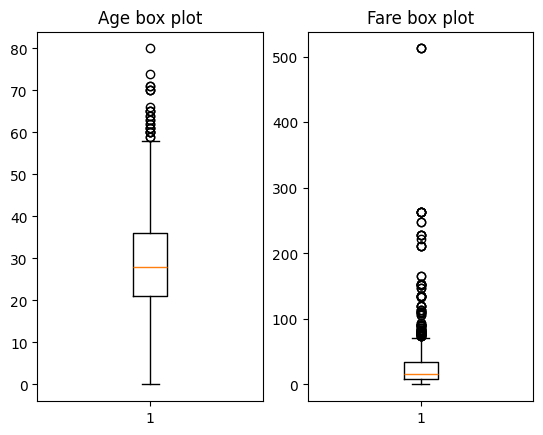

In [ ]:
numColNames = df.select_dtypes(include=np.number).columns
plt.figure()
for i, col in enumerate(numColNames):
    plt.subplot(1, 2, i+1)
    plt.boxplot(df[col])
    plt.title(f'{col} box plot')
plt.show()

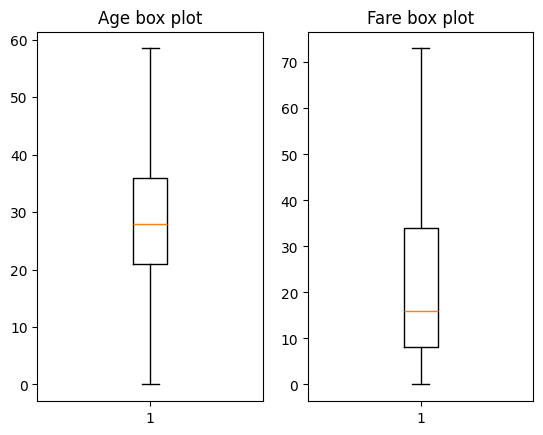

In [ ]:
for col in numColNames:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    UPF = Q3 + 1.5 * IQR
    LOF = Q1 - 1.5 * IQR
    lowOut = df[ df[col] < LOF ][col].values
    uppOut = df[ df[col] > UPF ][col].values
    df[col].replace(lowOut, LOF, inplace=True)
    df[col].replace(uppOut, UPF, inplace=True)

plt.figure()
for i, col in enumerate(numColNames):
    plt.subplot(1, 2, i+1)
    plt.boxplot(df[col])
    plt.title(f'{col} box plot')
plt.show()

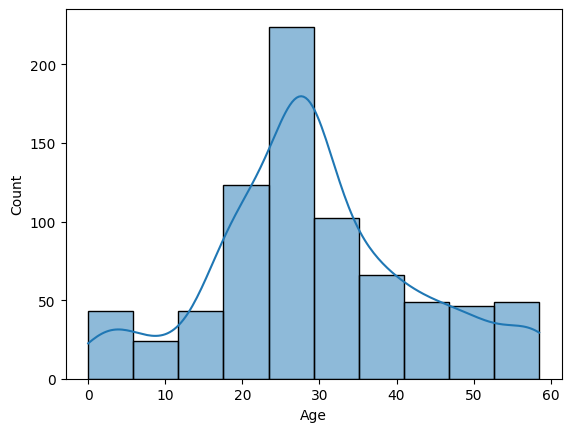

In [ ]:
plt.figure()
sns.histplot(data=df, x = 'Age', kde=True, bins=10)
plt.show()

# Task 4:  Data Visualization

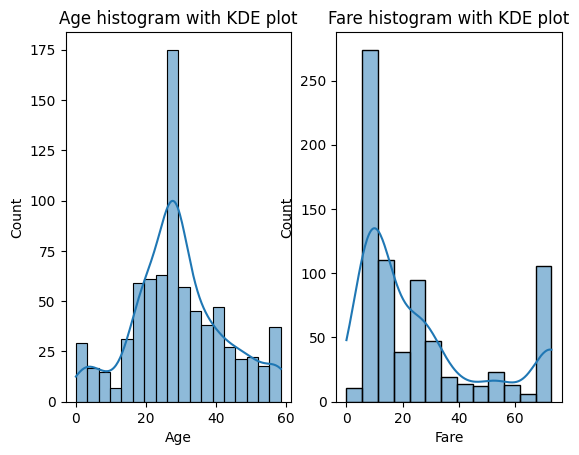

In [ ]:
plt.figure()
for i, col in enumerate(numColNames):
    plt.subplot(1, 2, i+1)
    sns.histplot(data=df, x = col, kde=True)
    plt.title(f'{col} histogram with KDE plot')
plt.show()

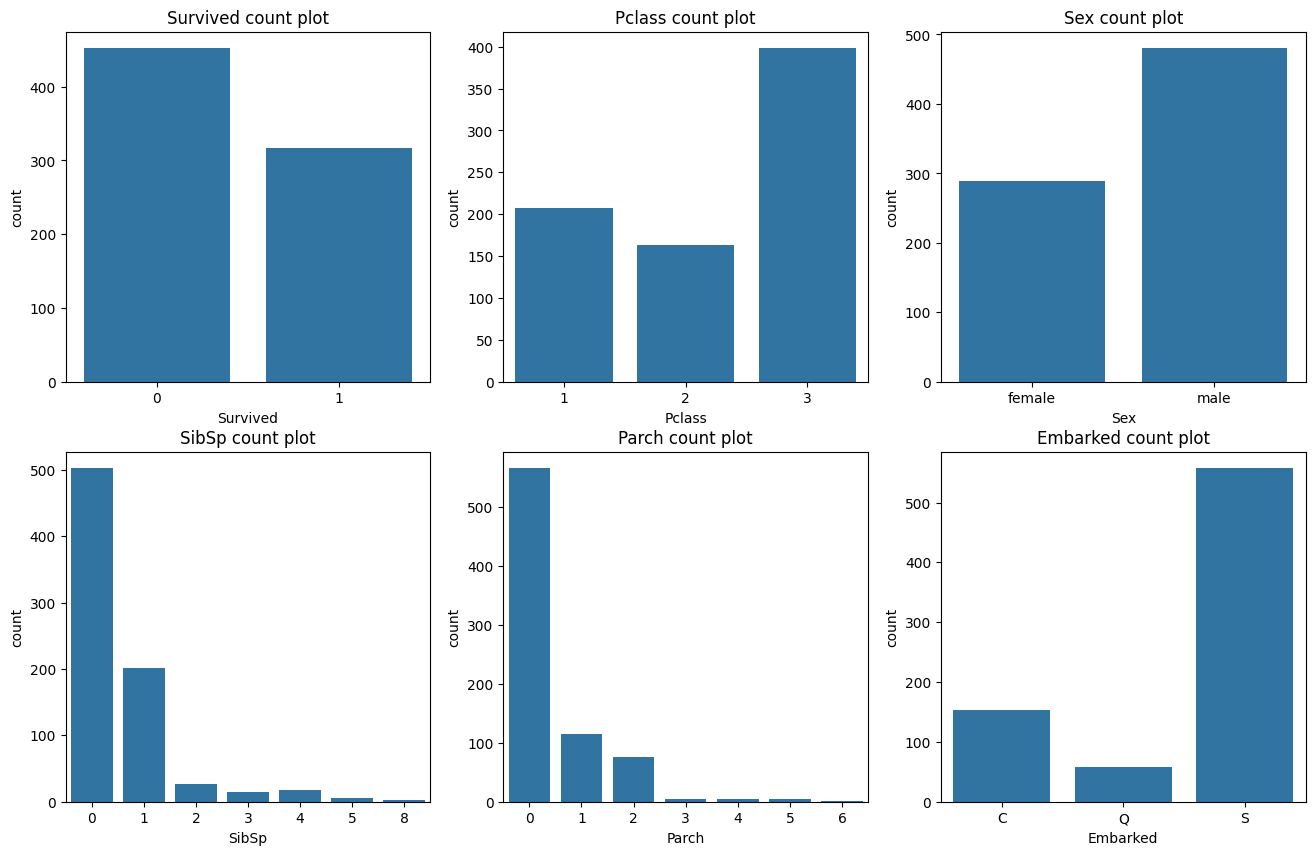

In [ ]:
catColNames = df.select_dtypes('category').columns
plt.figure(figsize=(16, 10))
for i, col in enumerate(catColNames):
    plt.subplot(2, 3, i+1)
    sns.countplot(data=df, x = col)
    plt.title(f'{col} count plot')
plt.show()

<Axes: xlabel='Sex', ylabel='Survived'>

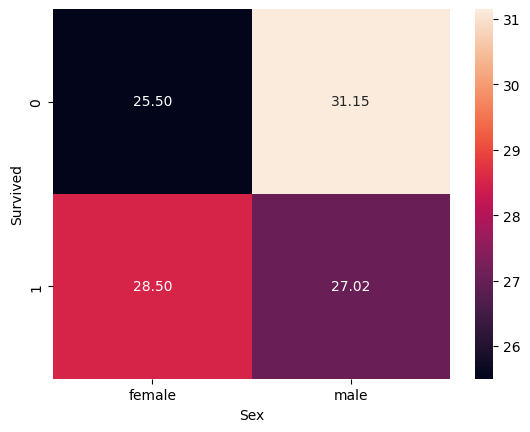

In [ ]:
aggMAT = df.pivot_table(
    index='Survived',
    columns='Sex',
    values= 'Age',
    aggfunc= 'mean'
)
plt.figure()
sns.heatmap(aggMAT, annot=True, fmt= '4.2f')

<Figure size 1600x1200 with 0 Axes>

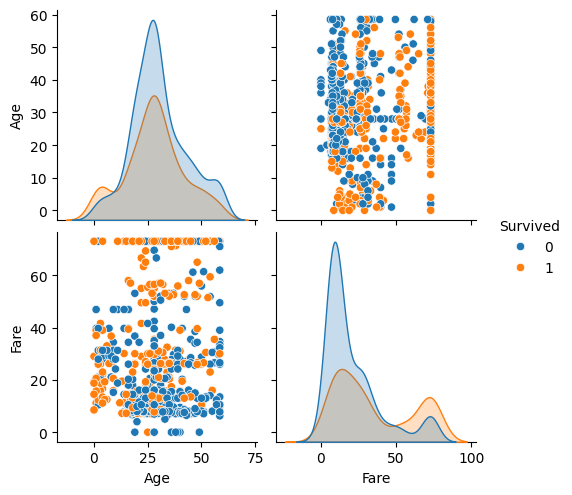

In [ ]:
plt.figure(figsize=(16, 12))
sns.pairplot(df, hue='Survived')
plt.show()

# Task 5: Predictive Model or Insight Project

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_curve, roc_auc_score, confusion_matrix

X = df[['Age']]
y = df['Survived']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
lgModel = LogisticRegression()

lgModel.fit(X_train, y_train)

y_pred = lgModel.predict(X_test)

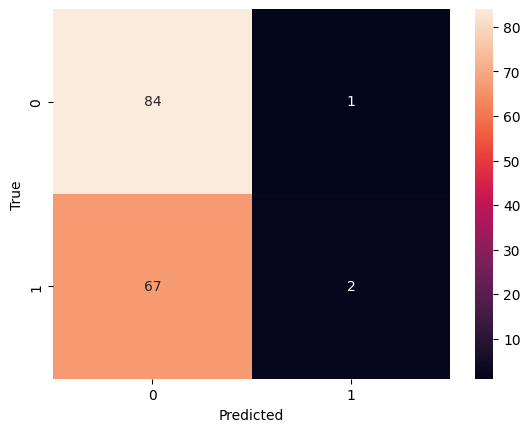

In [ ]:
cm= confusion_matrix(y_true=y_test, y_pred=y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
print(f"Classification Report: \n{classification_report(y_true=y_test, y_pred=y_pred)}")

Classification Report: 
              precision    recall  f1-score   support

           0       0.56      0.99      0.71        85
           1       0.67      0.03      0.06        69

    accuracy                           0.56       154
   macro avg       0.61      0.51      0.38       154
weighted avg       0.61      0.56      0.42       154

